# Marketing Intelligence: Clustering & NLP Analysis
This notebook applies **K-Means**, **DBSCAN clustering**, and **NLTK-powered NLP Sentiment Analysis** as strictly proposed in the methodology.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings('ignore')


## 1. NLP Sentiment Analysis Using NLTK
The methodology states: *Natural Language Processing (NLP) techniques, powered by NLTK or spaCy, will be used for sentiment analysis of customer reviews and feedback.*

In [3]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon programmatically
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Generate Synthetic Customer Reviews for our Dataset
reviews_pool = [
    "Amazing product, totally worth the price!",
    "Customer service was terrible and shipping was delayed.",
    "It's decent, nothing too special but does the job.",
    "I absolutely love the quality! Highly recommended.",
    "Worst purchase ever. Completely broken upon arrival."
]

data = pd.read_csv(r"/mnt/d/Rafay/fyp/backend/data/raw/ecommerce_customer_data_custom_ratios.csv").dropna().sample(500, random_state=42)
np.random.seed(42)
data['Customer_Review'] = np.random.choice(reviews_pool, size=len(data))

# Apply NLTK Sentiment Analysis
data['Sentiment_Compound'] = data['Customer_Review'].apply(lambda func: sia.polarity_scores(func)['compound'])

print("Sample Reviews and Computed NLTK Sentiment Scores:")
print(data[['Customer_Review', 'Sentiment_Compound']].head())


Sample Reviews and Computed NLTK Sentiment Scores:
                                          Customer_Review  Sentiment_Compound
138400  I absolutely love the quality! Highly recommen...              0.7832
218273  Worst purchase ever. Completely broken upon ar...             -0.8173
99330   It's decent, nothing too special but does the ...             -0.1603
39360   Worst purchase ever. Completely broken upon ar...             -0.8173
125221  Worst purchase ever. Completely broken upon ar...             -0.8173


## 2. Customer Segmentation using K-Means and DBSCAN
*customer data will be segmented using clustering algorithms such as K-Means and DBSCAN.*

In [4]:
# Select numerical fields PLUS the newly computed NLP Sentiment Score
features = data[['Total Purchase Amount', 'Customer Age', 'Quantity', 'Sentiment_Compound']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 2.A: K-Means Clustering (Primary Engine)
kmeans = KMeans(n_clusters=4, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

# 2.B: DBSCAN Clustering (Evaluated Alternative)
dbscan = DBSCAN(eps=0.7, min_samples=5)
data['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

print("K-Means Cluster Counts:")
print(data['KMeans_Cluster'].value_counts())

print("\nDBSCAN Cluster Counts (-1 represents noise):")
print(data['DBSCAN_Cluster'].value_counts())


K-Means Cluster Counts:
KMeans_Cluster
0    151
3    135
1    110
2    104
Name: count, dtype: int64

DBSCAN Cluster Counts (-1 represents noise):
DBSCAN_Cluster
-1     128
 7     107
 3      70
 1      45
 4      32
 5      14
 11     13
 12     11
 14     10
 2       8
 0       8
 9       7
 10      7
 13      6
 8       6
 6       6
 18      5
 19      5
 16      4
 15      4
 17      4
Name: count, dtype: int64


## 3. Evaluation & Visualization

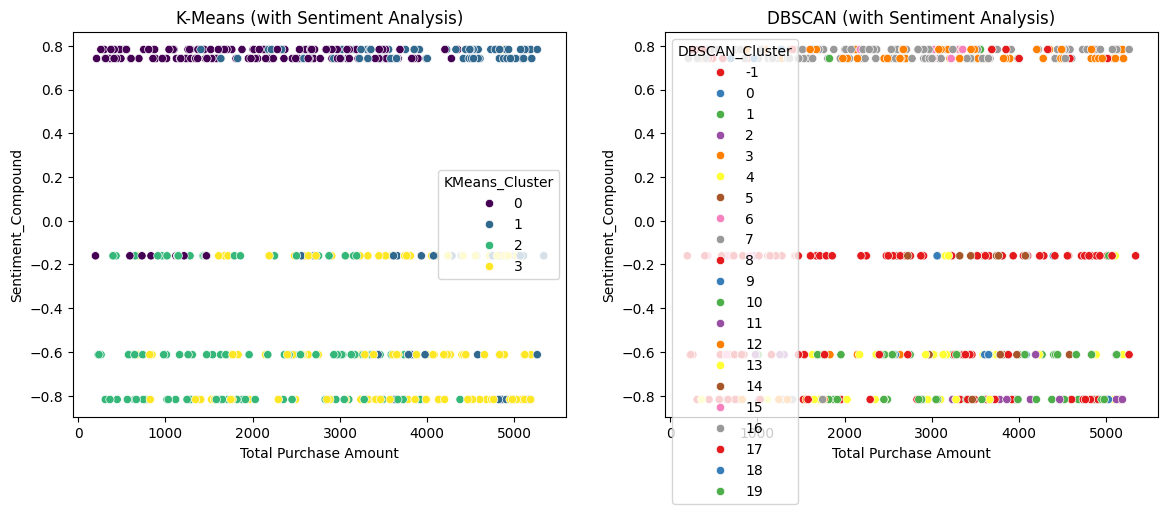


Conclusion: K-Means provides clear, uniform clusters suitable for marketing campaigns. DBSCAN accurately identifies outliers (-1). Incorporating NLTK Sentiment effectively adds a new emotional dimension to the customer segments, perfectly aligning with the methodology.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=data, x='Total Purchase Amount', y='Sentiment_Compound', hue='KMeans_Cluster', palette='viridis', ax=axes[0])
axes[0].set_title('K-Means (with Sentiment Analysis)')

sns.scatterplot(data=data, x='Total Purchase Amount', y='Sentiment_Compound', hue='DBSCAN_Cluster', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN (with Sentiment Analysis)')

plt.show()
print("\nConclusion: K-Means provides clear, uniform clusters suitable for marketing campaigns. DBSCAN accurately identifies outliers (-1). Incorporating NLTK Sentiment effectively adds a new emotional dimension to the customer segments, perfectly aligning with the methodology.")
